In [1]:
import pandas as pd
import numpy as np
import os
import datetime as dt
import solicitud_data as sd
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
%load_ext autoreload
%autoreload 2

# Descarga ERA

In [ ]:
import os
import cdsapi

# 1. Definir la ruta de la carpeta de destino
output_dir = "/home/jta/Documentos/articulo_planificacion/planificacion_energetica/data_era_ghi"

# Crear la carpeta si no existe
os.makedirs(output_dir, exist_ok=True)

# 2. Configurar el cliente de CDS
client = cdsapi.Client()
dataset = "reanalysis-era5-land"

# 3. Generar listas de años, meses y días
years = [str(year) for year in range(2000, 2025)]  # Genera del 2000 al 2024
months = [f"{m:02d}" for m in range(1, 13)]       # Genera ['01', '02', ..., '12']
days = [f"{d:02d}" for d in range(1, 32)]         # Genera ['01', '02', ..., '31']

# 4. Iterar año por año para evitar saturar la API
for year in years:
    print(f"--- Iniciando descarga del año {year} ---")
    
    # Definir el nombre y ruta completa del archivo de salida
    output_filename = os.path.join(output_dir, f"era5_land_ghi_{year}.nc")
    
    request = {
        "variable": ["surface_solar_radiation_downwards"],
        "year": year,      # Pide solo el año actual de la iteración
        "month": months,   # Incluye todos los meses del año
        "day": days,       # Incluye todos los días
        "data_format": "netcdf",
        "download_format": "unarchived",
        "area": [13.5, -80, -6.5, 66.5]
    }
    
    try:
        # Pass el nombre del archivo directamente al método .download()
        client.retrieve(dataset, request).download(output_filename)
        print(f"Descarga completada con éxito: {output_filename}\n")
    except Exception as e:
        print(f"Error al descargar el año {year}: {e}\n")

print("Proceso de descarga finalizado.")

# Recurso hídrico

## Datos XM

In [ ]:
path = 'data'
files = os.listdir(path)
path_files = [os.path.join(path,file) for file in files if 'xlsx' in file]

In [ ]:
list_df = list()

for file in path_files:
    df = pd.read_excel(
        file,
        skiprows=3,
        parse_dates=True,
        index_col=0
    )
    list_df.append(df)

# Concatenacion datos
df_concat = pd.concat(list_df,axis=0)

In [ ]:
# Separacion datos por embalse
embalses = df_concat['Nombre Embalse'].unique()
dict_embalses = dict()

for embalse in embalses:
    mask = df_concat['Nombre Embalse'] == embalse
    df_embalse = df_concat[mask]
    dict_embalses[embalse] = df_embalse

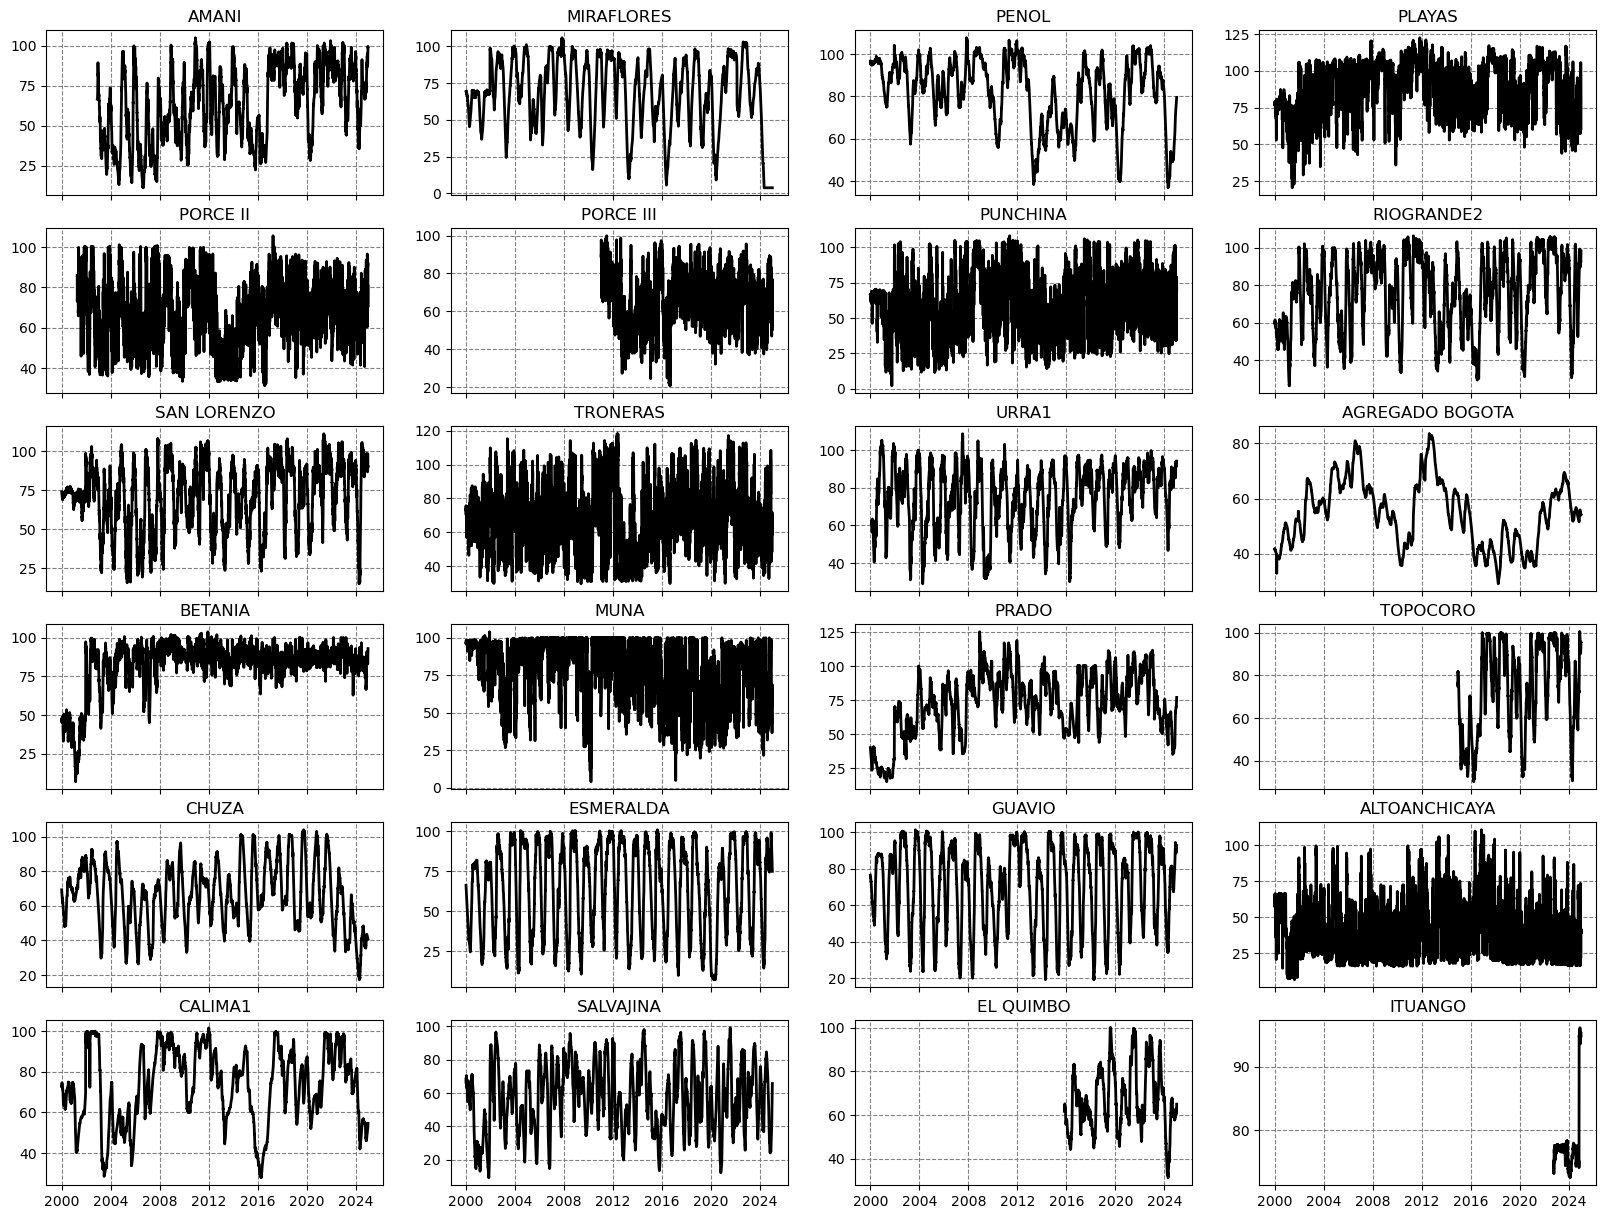

In [ ]:
# Revision consistencia de las series 
fig, axes = plt.subplots(
    nrows = 6,
    ncols = 4,
    figsize = (20,15),
    sharex=True
)
ax = axes.flatten()

idx = 0
for embalse,df in dict_embalses.items():

    df = df.sort_index()
    
    # Ploteo de los datos
    ax[idx].plot(
        df['Volumen %']*100,
        linewidth=2.0,
        color='black'
    )
    # Titulo
    ax[idx].set_title(embalse)
    # grilla
    ax[idx].grid(linestyle='--',color='grey')

    # Actualizacion subplot
    idx += 1

## Influencia del ENSO

In [71]:
# Lectura datos MEI
path = 'mei_mensual_2000_2024.csv'
df_mei = pd.read_csv(path,index_col='Date',parse_dates=True)

In [24]:
# Filtrar series de tiempo de cada embalse mediante el MEI

def clasificar_enso(
        df_mei,
        df,
        umbral
    ):
        
    # Lectura del dataframe con el oni

    df_clasificar = df.copy()
    #Columna que contiene los caudales
    columna = df_clasificar.columns[-1]
        
    # Inicializamos con "Neutral"
    df_mei['enso_phase'] = 'neutro'  
    for i in range(len(df_mei) - 4):
    # Tomamos una ventana de 5 meses consecutivos
        window = df_mei['MEI'].iloc[i:i+5]
        if all(window >= 0.5):
            df_mei.iloc[i:i+4, 1] = 'niño'
        elif all(window <= -0.5):
            df_mei.iloc[i:i+4, 1] = 'niña'
                
    # Clasificacion datos con el oni
    df_clasificar['month'] = df_clasificar.index.to_period('M')
    df_mei['month'] = df_mei.index.to_period('M')
    df_merged = pd.merge(
        df_clasificar, 
        df_mei, 
        on='month', 
        how='left'
    )
    df_merged.index = df_clasificar.index
        
    df_clasificado = df_merged[[columna,'enso_phase']]
    return df_clasificado

In [ ]:
df_embalse = dict_embalses['ALTOANCHICAYA']
df_embalse = df_embalse.sort_index()
df_clasificado = clasificar_enso(df_mei,df_embalse,5)


True

In [76]:
df_clasificado['Volumen %'] = df_clasificado['Volumen %']*100

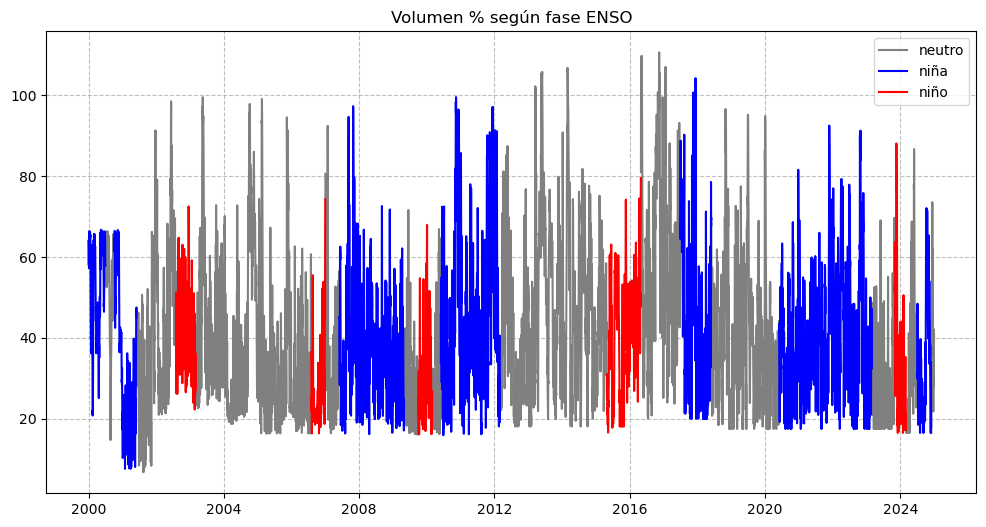

In [ ]:
# Ploteo de verificacion
mask_nina = df_clasificado['enso_phase'] == 'niña'
mask_nino = df_clasificado['enso_phase'] == 'niño'
mask_neutro = df_clasificado['enso_phase'] == 'neutro'
# dataframes 
import matplotlib.pyplot as plt
import numpy as np

# Cambié el figsize a (12, 6) porque para series de tiempo es mejor que sea más ancho que alto
plt.figure(figsize=(12, 6))

# .where() pone NaN donde la condición es falsa, cortando la línea automáticamente
plt.plot(
    df_clasificado['Volumen %'].where(mask_neutro), 
    color='grey', 
    label='neutro'
)
plt.plot(
    df_clasificado['Volumen %'].where(mask_nina), 
    color='blue', 
    label='niña'
)
plt.plot(
    df_clasificado['Volumen %'].where(mask_nino), 
    color='red', 
    label='niño'
)

plt.legend(loc='best')
plt.grid(
    linestyle='--', 
    color='grey', 
    alpha=0.5
)

## Comportamiento multianual del porcentaje bajo fase

In [83]:
dict_embalses_enso = dict()

for embalse,df in dict_embalses.items():

    df_embalse = df[['Volumen %']].sort_index()
    # clasificacion
    df_clasificado = clasificar_enso(
        df_mei=df_mei,
        df=df_embalse,
        umbral=5
    )
    dict_embalses_enso[embalse] = df_clasificado

In [85]:
# Definicion ciclo anual

def ciclo_anual(df):

    # Filtrado exploratorio por media
    df_resample = df.groupby(df.index.month).mean()
    return df_resample


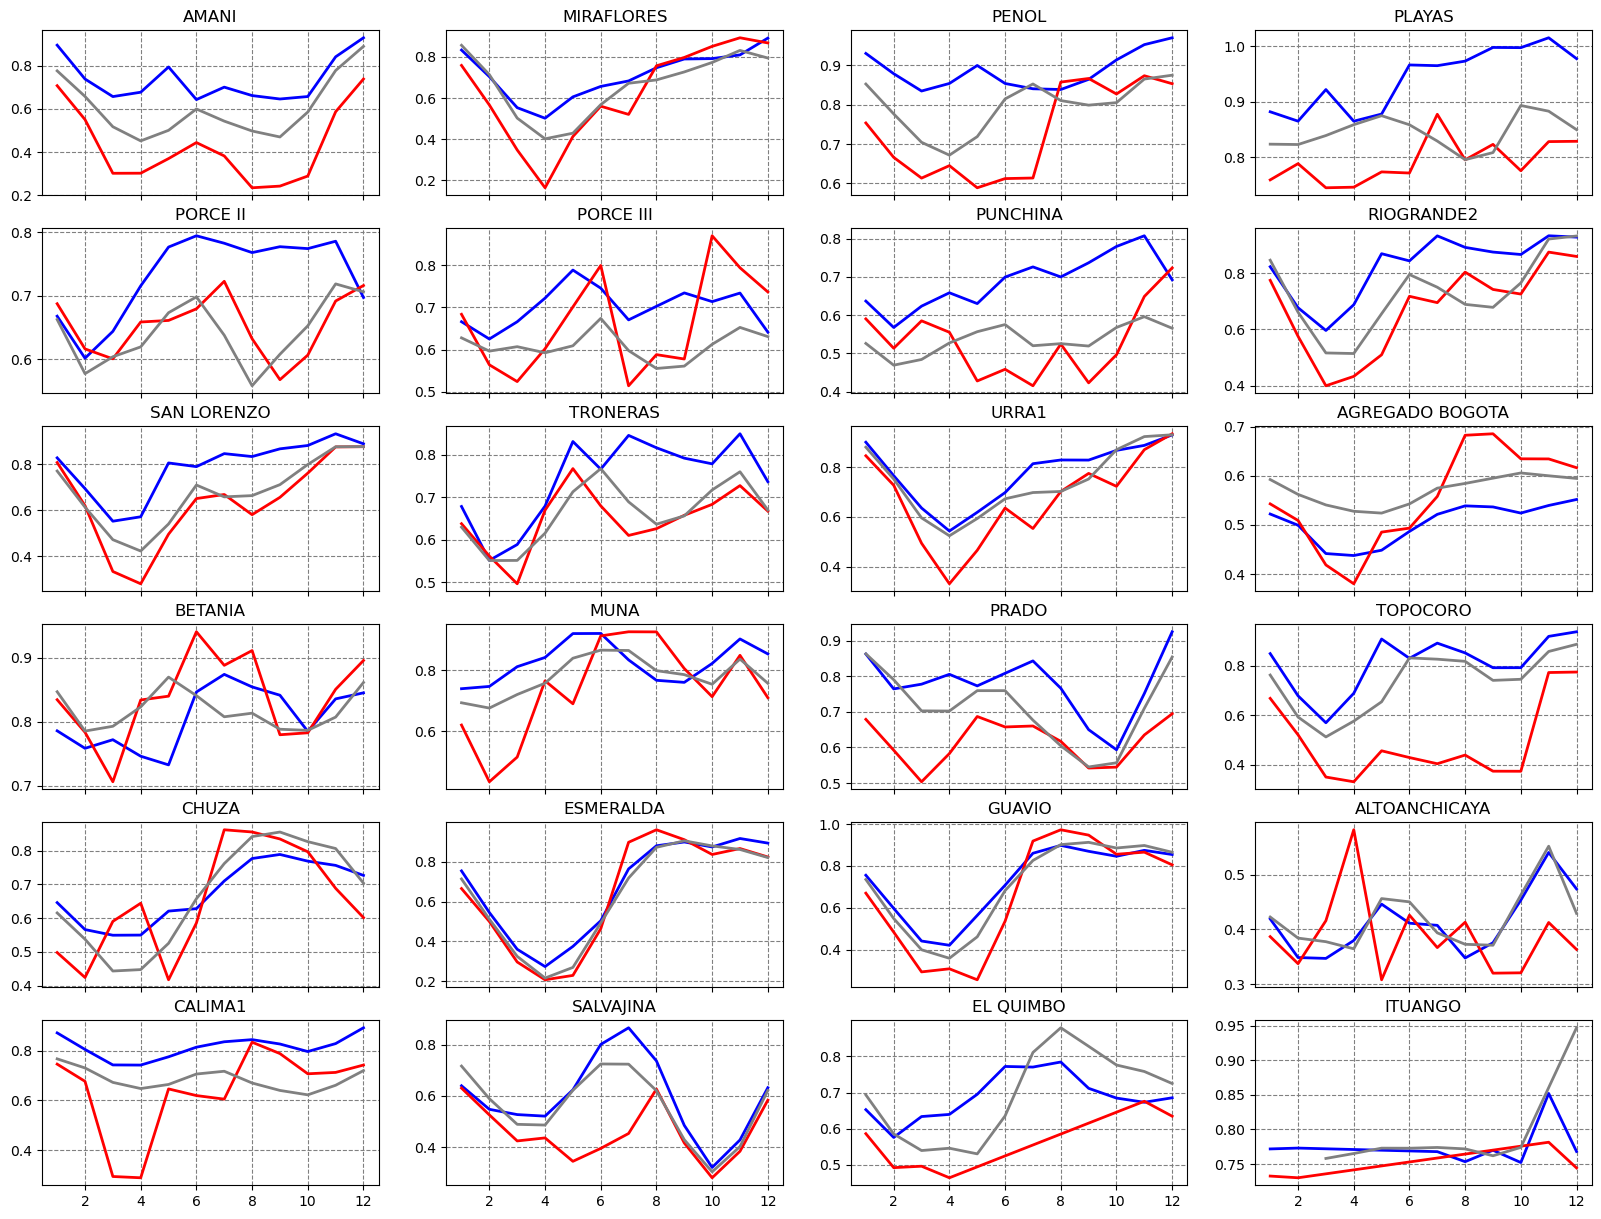

In [89]:
# Revision consistencia de las series 
fig, axes = plt.subplots(
    nrows = 6,
    ncols = 4,
    figsize = (20,15),
    sharex=True
)
ax = axes.flatten()

idx = 0
for embalse,df in dict_embalses_enso.items():

    # Mascaras 
    mask_nina = df['enso_phase'] == 'niña'
    mask_nino = df['enso_phase'] == 'niño'
    mask_neutro = df['enso_phase'] == 'neutro'

    # Filtrado
    df_neutro = df[mask_neutro]
    df_nino = df[mask_nino]
    df_nina = df[mask_nina]
    
    # Estimacion clico anual
    ciclo_nina = ciclo_anual(df_nina[['Volumen %']])
    ciclo_nino = ciclo_anual(df_nino[['Volumen %']])
    ciclo_neutro = ciclo_anual(df_neutro[['Volumen %']])

   # Ploteo de los ciclos
    ax[idx].plot(
        ciclo_nina,
        linewidth=2.0, 
        color='blue', 
        label='Niña'
    )
    ax[idx].plot(
        ciclo_nino,
        linewidth=2.0,
        color='red', 
        label='Niño'
    )
    ax[idx].plot(
        ciclo_neutro,
        linewidth=2.0,
        color='grey', 
        label='neutro'
    )
        # Titulo
    ax[idx].set_title(embalse)
    # grilla
    ax[idx].grid(linestyle='--',color='grey')

    # Actualizacion subplot
    idx += 1

# Recurso eólico

Paso a paso del filtro del recurso eólico:
- Transformación a densidad de potencia eólica
- Remoción de la estacionalidad mensual
- Uso de filtro de pasabanda para retener señal intraestacional
- Generación anomalías compuestas por Fase ENSO

In [3]:
def wpd(da,ro):

    wpd = 1/2 * (ro) * (da)**3

    return wpd

In [4]:
# Lectura de los datos y conversion a wpd
path_data_era = '/home/jta/Documentos/articulo_planificacion/era5_data_netcdf'
files = os.listdir(path_data_era)
# Almacenamiento de datos

dict_data_era = {
    'fecha':[],
    'path_file':[]
}

# Generacion dataframe que contiene fecha y archivo
for file in files:
    if 'nc' in file:
        file_name = file.split('_')
        year = file_name[2]
        month = file_name[3].split('.')[0]
        # Generacion fecha
        date = pd.to_datetime(
            year + '/' + month + '/' + '01', 
            yearfirst=True, 
            format='%Y/%m/%d'
        ).date()

        file_path = os.path.join(path_data_era,file)

        dict_data_era['fecha'].append(date)
        dict_data_era['path_file'].append(file_path)

df_data_era = pd.DataFrame(dict_data_era)
df_data_era = df_data_era.set_index('fecha',drop=True).sort_index()
df_data_era.index = pd.to_datetime(df_data_era.index)


In [5]:
# Arreglo para solo retener del 2000 en adelante
mask = df_data_era.index >= '2000'
df_data_slice = df_data_era[mask]

In [ ]:
list_ds = list()
for file in df_data_slice['path_file']:
    ds = xr.open_dataset(file,engine='netcdf4')
    u_vel = ds['u100']
    v_vel = ds['v100']
    vel = np.sqrt(np.square(u_vel) + np.square(v_vel))
    # Estima la densidad de potencia con una densidad fija
    # Sujeto a mejoras
    # resampleo a mensual
    ds_vel_month = vel.resample(valid_time='ME').mean()
    list_ds.append(ds_vel_month)
# Generacion dataset
ds_concat = xr.concat(list_ds,dim='valid_time')

In [15]:
data = ds_concat[:,15,10]

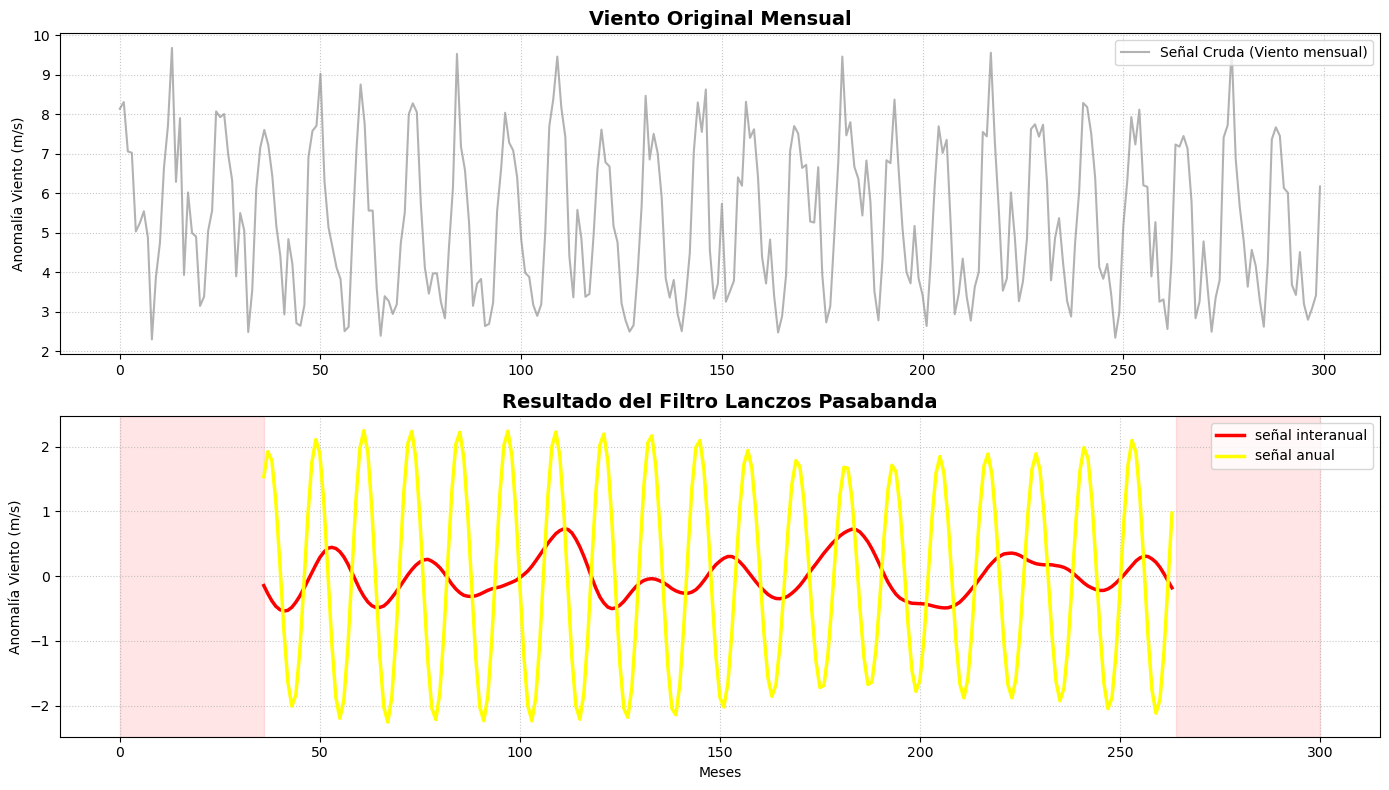

In [20]:
# Remoción de la estacionalidad
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# DEFINICIÓN DEL FILTRO DE LANCZOS (PASOS 1 AL 4)
# =============================================================================

def pesos_lanczos_pasobajo(N, fc):
    """
    Calcula los pesos de un filtro de paso bajo de Lanczos.
    N : Semi-ventana del filtro (meses hacia atrás y hacia adelante)
    fc: Frecuencia de corte (1 / meses)
    """
    # Vector de índices k (desde -N hasta N)
    k = np.arange(-N, N + 1)
    
    # --- PASO 1: Filtro Ideal (Función Sinc normalizada) ---
    # Ecuación: h_k = sin(2*pi*fc*k) / (pi*k)
    h_k = np.zeros_like(k, dtype=float)
    h_k[k == 0] = 2 * fc  # Límite en k=0
    h_k[k != 0] = np.sin(2 * np.pi * fc * k[k != 0]) / (np.pi * k[k != 0])
    
    # --- PASO 2: La Ventana de Lanczos ---
    # Ecuación: w_k = sin(pi*k/N) / (pi*k/N)
    w_k = np.zeros_like(k, dtype=float)
    w_k[k == 0] = 1.0  # Límite en k=0
    w_k[k != 0] = np.sin(np.pi * k[k != 0] / N) / (np.pi * k[k != 0] / N)
    
    # --- PASO 3: Calcular los pesos crudos ---
    # Ecuación: w'_k = h_k * w_k
    w_prime_k = h_k * w_k
    
    # --- PASO 4: La corrección de Duchon ---
    # Ecuación: C = (1 - sum(w'_k)) / (2N + 1)
    suma_pesos_crudos = np.sum(w_prime_k)
    C = (1.0 - suma_pesos_crudos) / (2 * N + 1)
    
    # Pesos finales normalizados: W_k = w'_k + C
    W_k = w_prime_k + C
    
    return W_k

# =============================================================================
# CREACIÓN DE LA SEÑAL SINTÉTICA DE VIENTO
# =============================================================================

# Simulamos 30 años de datos mensuales (360 meses)
meses = np.arange(300)

# Componentes de la señal
ruido = np.random.normal(0, 1.5, size=len(meses))                 # Alta frecuencia
ciclo_anual = 3 * np.sin(2 * np.pi * meses / 12)                  # Ciclo de 1 año
enso_real = 2 * np.sin(2 * np.pi * meses / 48)                    # Ciclo de 4 años (Nuestra meta)
tendencia_lenta = 0.01 * meses                                    # Tendencia multidecadal

# Señal total observada
viento_observado = ruido + ciclo_anual + enso_real + tendencia_lenta

# =============================================================================
# APLICACIÓN DEL FILTRO PASABANDA (PASO 5)
# =============================================================================

# Parámetros del filtro
N = 36  # Semi-ventana (perdemos 3 años al inicio y 3 al final)
fc_rapida = 1.0 / 18.0  # Frecuencia de corte superior (1.5 años)
fc_lenta = 1.0 / 96.0   # Frecuencia de corte inferior (8 años)

fc_rapida_anual = 1.0 / 10.0
fc_lenta_anual = 1.0 / 14.0

W_rap_anual = pesos_lanczos_pasobajo(N, fc_rapida_anual)
W_len_anual = pesos_lanczos_pasobajo(N, fc_lenta_anual)

W_pasabanda_anual = W_rap_anual - W_len_anual


# 1. Creamos el filtro de paso bajo para frecuencias rápidas
W_rapido = pesos_lanczos_pasobajo(N, fc_rapida)

# 2. Creamos el filtro de paso bajo para frecuencias muy lentas
W_lento = pesos_lanczos_pasobajo(N, fc_lenta)

# --- LA RESTA MÁGICA PARA CREAR EL PASABANDA ---
W_pasabanda = W_rapido - W_lento

# --- PASO 5: La Convolución ---
# mode='valid' aplica el filtro solo donde hay datos completos (evita bordes falsos)
viento_filtrado = np.convolve(data, W_pasabanda, mode='valid')
viento_filtrado_anual = np.convolve(data, W_pasabanda_anual, mode='valid')

# Para poder graficarlo alineado con la señal original, rellenamos los bordes perdidos con NaN
viento_filtrado_alineado = np.empty_like(data)
viento_filtrado_alineado[:] = np.nan
viento_filtrado_alineado[N:-N] = viento_filtrado

viento_filtrado_alineado_anual = np.empty_like(data)
viento_filtrado_alineado_anual[:] = np.nan
viento_filtrado_alineado_anual[N:-N] = viento_filtrado_anual


# =============================================================================
# VISUALIZACIÓN DE RESULTADOS
# =============================================================================

plt.figure(figsize=(14, 8))

# Subplot 1: Señal original caótica
plt.subplot(2, 1, 1)
plt.plot(meses, data, color='gray', alpha=0.6, label='Señal Cruda (Viento mensual)')
plt.title('Viento Original Mensual', fontsize=14, fontweight='bold')
plt.ylabel('Anomalía Viento (m/s)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

# Subplot 2: El filtro en acción aislando la señal
plt.subplot(2, 1, 2)
plt.plot(meses, viento_filtrado_alineado, color='red', linewidth=2.5, label='señal interanual')
plt.plot(meses, viento_filtrado_alineado_anual, color='yellow', linewidth=2.5, label='señal anual')
plt.title('Resultado del Filtro Lanczos Pasabanda', fontsize=14, fontweight='bold')
plt.xlabel('Meses')
plt.ylabel('Anomalía Viento (m/s)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

# Resaltar la zona de datos perdidos por la convolución
plt.axvspan(0, N, color='red', alpha=0.1, label='Datos perdidos (Bordes)')
plt.axvspan(len(meses)-N, len(meses), color='red', alpha=0.1)

plt.tight_layout()
plt.show()

# Recurso solar